# Task 2 results

Ablation, budget/acquisition decomposition, and the fusion null, from
`results/fusion_results.csv` (exported from the Modal runs by `scripts/export_results.py`).
All comparisons paired within seed.

In [1]:
from pathlib import Path
import numpy as np, pandas as pd
from scipy import stats

root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "results/fusion_results.csv").exists())
df = pd.read_csv(root / "results/fusion_results.csv")
aug = df[df.augment].copy()
len(aug)

25

### Ablation (5 seeds)

In [2]:
def name(r):
    if r.views == "sag":   return "sag-1slice" if r.sag_slices == 1 else "sag-5slice"
    if r.views == "axial": return "axial"
    return f"fusion-{r.fusion}"

aug["config"] = aug.apply(name, axis=1)
order = ["sag-1slice", "sag-5slice", "axial", "fusion-concat", "fusion-attn"]
def std0(series):
    return series.std(ddof=0)

(aug.groupby("config")
    .agg(n=("seed", "nunique"),
         kappa=("kappa", "mean"), kappa_sd=("kappa", std0),
         worst_lvl=("worst_lvl", "mean"), worst_lvl_sd=("worst_lvl", std0))
    .reindex(order).round(3))

,n,kappa,kappa_sd,worst_lvl,worst_lvl_sd
config,,,,,
sag-1slice,5,0.618,0.069,0.471,0.057
sag-5slice,5,0.656,0.045,0.576,0.071
axial,5,0.678,0.063,0.654,0.042
fusion-concat,5,0.697,0.067,0.673,0.036
fusion-attn,5,0.626,0.055,0.519,0.057


### Decomposition

`total = axial - sag-1slice = budget (sag-5slice - sag-1slice) + acquisition (axial - sag-5slice)`.
Paired t-test, 95% CI on per-seed deltas.

In [3]:
def col(metric, views, fusion=None, sag_slices=1):
    d = aug[(aug.views == views) & (aug.sag_slices == sag_slices)]
    if fusion is not None:
        d = d[d.fusion == fusion]
    return d.set_index("seed")[metric].sort_index()

def paired(a, b):
    d = (a - b).dropna().to_numpy()
    n = len(d)
    t, p = stats.ttest_1samp(d, 0.0)
    h = stats.t.ppf(0.975, n - 1) * d.std(ddof=1) / np.sqrt(n)
    return {"delta": d.mean(), "lo": d.mean() - h, "hi": d.mean() + h, "p": p}

rows = []
for m in ["worst_lvl", "kappa"]:
    s1, s5, ax = col(m, "sag"), col(m, "sag", sag_slices=5), col(m, "axial")
    rows += [{"metric": m, "effect": "total",       **paired(ax, s1)},
             {"metric": m, "effect": "budget",      **paired(s5, s1)},
             {"metric": m, "effect": "acquisition", **paired(ax, s5)}]
pd.DataFrame(rows).set_index(["metric", "effect"]).round(3)

delta     lo     hi      p
metric    effect                                 
worst_lvl total        0.183  0.139  0.226  0.000
          budget       0.105  0.052  0.158  0.005
          acquisition  0.078  0.000  0.155  0.050
kappa     total        0.060 -0.034  0.154  0.149
          budget       0.037 -0.051  0.125  0.306
          acquisition  0.023 -0.034  0.079  0.324

budget and acquisition share the `sag-5slice` term (opposite sign), so they are anticorrelated:

In [4]:
s1, s5, ax = col("worst_lvl", "sag"), col("worst_lvl", "sag", sag_slices=5), col("worst_lvl", "axial")
np.corrcoef((s5 - s1), (ax - s5))[0, 1].round(2)

-0.84

### Fusion vs. the better single view (axial)

In [5]:
for fusion in ["concat", "attn"]:
    for m in ["worst_lvl", "kappa"]:
        r = paired(col(m, "both", fusion=fusion), col(m, "axial"))
        print(f"{fusion:>6} - axial  {m:<9} {r['delta']:+.3f}  [{r['lo']:+.3f}, {r['hi']:+.3f}]  p={r['p']:.3f}")

concat - axial  worst_lvl +0.019  [-0.067, +0.106]  p=0.572
concat - axial  kappa     +0.018  [-0.044, +0.081]  p=0.457
  attn - axial  worst_lvl -0.135  [-0.157, -0.113]  p=0.000
  attn - axial  kappa     -0.053  [-0.123, +0.017]  p=0.104


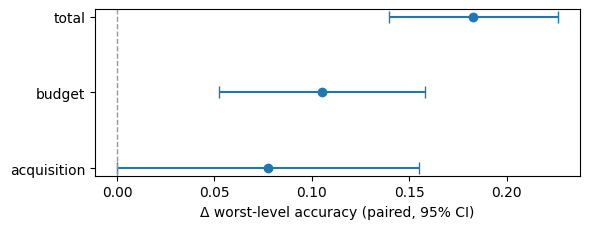

In [6]:
import matplotlib.pyplot as plt
d = pd.DataFrame(rows).query("metric == 'worst_lvl'").set_index("effect")
y = np.arange(len(d))[::-1]
plt.figure(figsize=(6, 2.4))
plt.errorbar(d.delta, y, xerr=[d.delta - d.lo, d.hi - d.delta], fmt="o", capsize=4)
plt.axvline(0, color="0.6", ls="--", lw=1)
plt.yticks(y, d.index); plt.xlabel("Δ worst-level accuracy (paired, 95% CI)")
plt.tight_layout(); plt.show()